# Train A Deepfake Classifier With PyTorch

This notebook trains a binary deepfake classifier on the Kaggle dataset: `muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal`.

Pipeline:
- download and extract dataset
- infer labels from folder names
- train a ResNet18 model with PyTorch
- evaluate on a validation split
- save checkpoint and predictions

In [1]:
import importlib.util
import subprocess
import sys

required = {
    "torch": "torch",
    "torchvision": "torchvision",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "PIL": "pillow",
    "kaggle": "kaggle",
    "tqdm": "tqdm",
    "matplotlib": "matplotlib",
}

missing = sorted({pip_name for module_name, pip_name in required.items() if importlib.util.find_spec(module_name) is None})
if missing:
    print("Installing missing packages:", ", ".join(missing))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are already installed.")

All required packages are already installed.


In [2]:
import importlib
import importlib.util
import json
import os
import random
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from tqdm.auto import tqdm

IN_KAGGLE = os.getenv("KAGGLE_KERNEL_RUN_TYPE") is not None or Path("/kaggle/working").exists()
IN_COLAB = importlib.util.find_spec("google.colab") is not None and not IN_KAGGLE
FAST_RUNTIME = IN_COLAB or IN_KAGGLE

try:
    torchvision = importlib.import_module("torchvision")
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError("torchvision is not installed. Run Cell 2 first.") from exc

models = torchvision.models
transforms = torchvision.transforms

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

KAGGLE_DATASET = "muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal"
REAL_FOLDER_KEYWORDS = ["real", "genuine", "authentic", "original", "human"]
FAKE_FOLDER_KEYWORDS = ["fake", "ai", "generated", "deepfake", "synthetic", "artificial"]
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

# Tune these for speed/quality tradeoff
MAX_PER_CLASS = 200000
VAL_FRACTION = 0.20
IMAGE_SIZE = 224
BATCH_SIZE = 64 if torch.cuda.is_available() else 32
NUM_EPOCHS = 5
LEARNING_RATE = 3e-4
NUM_WORKERS = min(4, os.cpu_count() or 2)

if IN_KAGGLE:
    runtime_name = "Kaggle"
    BASE_DIR = Path("/kaggle/working")
elif IN_COLAB:
    runtime_name = "Google Colab"
    BASE_DIR = Path("/content")
else:
    runtime_name = "Local / VS Code"
    BASE_DIR = Path.cwd()


BASE_DIR = Path("/content") if IN_COLAB else Path.cwd()
DATA_DIR = BASE_DIR / "data" / "real-vs-ai-mbilal"
OUTPUT_DIR = BASE_DIR / "outputs" / "pytorch_deepfake"
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Runtime: {'Google Colab' if IN_COLAB else 'Local / VS Code'}")
print(f"Device: {device}")
print(f"BASE_DIR: {BASE_DIR}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")
print(f"MAX_PER_CLASS: {MAX_PER_CLASS}")
print(f"BATCH_SIZE: {BATCH_SIZE}  NUM_EPOCHS: {NUM_EPOCHS}  NUM_WORKERS: {NUM_WORKERS}")

Runtime: Local / VS Code
Device: cuda
BASE_DIR: /kaggle/working
DATA_DIR: /kaggle/working/data/real-vs-ai-mbilal
OUTPUT_DIR: /kaggle/working/outputs/pytorch_deepfake
MAX_PER_CLASS: 200000
BATCH_SIZE: 64  NUM_EPOCHS: 5  NUM_WORKERS: 4


In [3]:
def download_and_extract_dataset() -> None:
    download_marker = DATA_DIR / '.downloaded'
    extract_marker = DATA_DIR / '.extracted'

    import kaggle

    kaggle.api.authenticate()

    if not download_marker.exists():
        print(f'Downloading {KAGGLE_DATASET} ...')
        kaggle.api.dataset_download_files(
            KAGGLE_DATASET,
            path=str(DATA_DIR),
            unzip=False,
            quiet=False,
        )
        download_marker.touch()

    if not extract_marker.exists():
        zip_files = list(DATA_DIR.glob('*.zip'))
        if not zip_files:
            raise FileNotFoundError(f'No zip files found in {DATA_DIR}')

        for zip_file in zip_files:
            print(f'Extracting {zip_file.name} ...')
            with zipfile.ZipFile(zip_file, 'r') as archive:
                archive.extractall(DATA_DIR)
        extract_marker.touch()

    print('Dataset is ready.')


download_and_extract_dataset()

Dataset URL: https://www.kaggle.com/datasets/muhammadbilal6305/200k-real-vs-ai-visuals-by-mbilal


100%|██████████| 1.82G/1.82G [00:09<00:00, 203MB/s]



Extracting 200k-real-vs-ai-visuals-by-mbilal.zip ...
Dataset is ready.


In [4]:
def infer_label(name: str) -> int | None:
    lo = name.lower()
    for kw in REAL_FOLDER_KEYWORDS:
        if kw in lo:
            return 0
    for kw in FAKE_FOLDER_KEYWORDS:
        if kw in lo:
            return 1
    return None


def inventory_images(root: Path) -> pd.DataFrame:
    rows = []
    for p in root.rglob('*'):
        if p.suffix.lower() not in IMAGE_EXTS:
            continue

        label = None
        rel_parts = p.relative_to(root).parts[:-1]
        for part in reversed(rel_parts):
            guessed = infer_label(part)
            if guessed is not None:
                label = guessed
                break

        rows.append({
            'path': str(p),
            'label': label,
            'label_name': {0: 'real', 1: 'fake'}.get(label, 'unknown'),
        })

    return pd.DataFrame(rows)


df_all = inventory_images(DATA_DIR)
df = df_all[df_all['label'].notna()].copy()
df['label'] = df['label'].astype(int)

if len(df) == 0:
    raise RuntimeError('No labels inferred. Update REAL_FOLDER_KEYWORDS/FAKE_FOLDER_KEYWORDS.')

if MAX_PER_CLASS is not None:
    sampled_parts = []
    for _, group in df.groupby('label', sort=True):
        take = min(MAX_PER_CLASS, len(group))
        sampled_parts.append(group.sample(take, random_state=SEED))
    df = pd.concat(sampled_parts, ignore_index=True)

train_df, val_df = train_test_split(
    df,
    test_size=VAL_FRACTION,
    random_state=SEED,
    stratify=df['label'],
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print(f'Total discovered images: {len(df_all)}')
print(f'Working labeled images: {len(df)}')
print(df.groupby('label_name').size().rename('count').to_string())
print(f'Train size: {len(train_df)}  Val size: {len(val_df)}')

Total discovered images: 200000
Working labeled images: 200000
label_name
fake    100000
real    100000
Train size: 160000  Val size: 40000


In [5]:
class DeepfakeDataset(Dataset):
    def __init__(self, frame: pd.DataFrame, transform=None):
        self.paths = frame['path'].tolist()
        self.labels = frame['label'].astype(np.float32).tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx: int):
        path = self.paths[idx]
        label = self.labels[idx]

        with Image.open(path) as img:
            image = img.convert('RGB')

        if self.transform is not None:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.float32)


train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE + 32, IMAGE_SIZE + 32)),
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_ds = DeepfakeDataset(train_df, transform=train_transform)
val_ds = DeepfakeDataset(val_df, transform=val_transform)

class_counts = train_df['label'].value_counts().to_dict()
sample_weights = train_df['label'].map(
    lambda y: 1.0 / max(class_counts.get(int(y), 1), 1)
).to_numpy(dtype=np.float64)

sampler = WeightedRandomSampler(
    weights=torch.from_numpy(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(device.type == 'cuda'),
    persistent_workers=(NUM_WORKERS > 0),
)

print(f'Train batches: {len(train_loader)}  Val batches: {len(val_loader)}')
print(f'Class counts (train): {class_counts}')

Train batches: 2500  Val batches: 625
Class counts (train): {0: 80000, 1: 80000}


In [6]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)
model.fc = nn.Linear(model.fc.in_features, 1)
model = model.to(device)

real_count = max(class_counts.get(0, 1), 1)
fake_count = max(class_counts.get(1, 1), 1)
pos_weight_value = float(real_count / fake_count)
criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_value], device=device))
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)

print(f'Using ResNet18 with pos_weight={pos_weight_value:.4f}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 154MB/s]


Using ResNet18 with pos_weight=1.0000


In [7]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for images, labels in tqdm(loader, desc='Train', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += float(loss.item()) * images.size(0)

    return running_loss / max(1, len(loader.dataset))


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_scores = []
    all_labels = []

    for images, labels in tqdm(loader, desc='Eval', leave=False):
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        logits = model(images).squeeze(1)
        loss = criterion(logits, labels)

        probs = torch.sigmoid(logits)

        running_loss += float(loss.item()) * images.size(0)
        all_scores.extend(probs.detach().cpu().numpy().tolist())
        all_labels.extend(labels.detach().cpu().numpy().astype(int).tolist())

    avg_loss = running_loss / max(1, len(loader.dataset))
    y_true = np.asarray(all_labels, dtype=np.int64)
    y_score = np.asarray(all_scores, dtype=np.float32)
    return avg_loss, y_true, y_score


history = []
best_val_f1 = -1.0
best_state_dict = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, y_true, y_score = evaluate(model, val_loader, criterion, device)

    y_pred = (y_score >= 0.5).astype(np.int64)

    metrics = {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
        'roc_auc': float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
    }

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'val_loss': val_loss,
        **metrics,
    })

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"acc={metrics['accuracy']:.4f} f1={metrics['f1']:.4f} auc={metrics['roc_auc']:.4f}"
    )

    if metrics['f1'] > best_val_f1:
        best_val_f1 = metrics['f1']
        best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

if best_state_dict is None:
    raise RuntimeError('Training did not produce a best checkpoint.')

model.load_state_dict(best_state_dict)
history_df = pd.DataFrame(history)
history_df

Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1/5 | train_loss=0.2436 val_loss=0.1779 acc=0.9156 f1=0.9169 auc=0.9813


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

...

Epoch 4/5 | train_loss=0.1197 val_loss=0.1163 acc=0.9439 f1=0.9434 auc=0.9916


Train:   0%|          | 0/2500 [00:00<?, ?it/s]

Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 5/5 | train_loss=0.1115 val_loss=0.1085 acc=0.9470 f1=0.9481 auc=0.9932


,epoch,train_loss,val_loss,accuracy,precision,recall,f1,roc_auc
0,1,0.243565,0.177883,0.91565,0.903426,0.93080,0.916909,0.981250
1,2,0.154874,0.172557,0.92160,0.898224,0.95095,0.923835,0.985358
2,3,0.135385,0.137973,0.93675,0.956088,0.91555,0.935380,0.988442
3,4,0.119724,0.116251,0.94390,0.951577,0.93540,0.943419,0.991632
4,5,0.111535,0.108483,0.94700,0.929477,0.96740,0.948060,0.993193


Eval:   0%|          | 0/625 [00:00<?, ?it/s]

Final validation metrics:
{
  "val_loss": 0.10848309592157603,
  "accuracy": 0.947,
  "precision": 0.9294773251345119,
  "recall": 0.9674,
  "f1": 0.9480595844766758,
  "roc_auc": 0.9931929075000001
}

              precision    recall  f1-score   support

        real       0.97      0.93      0.95     20000
        fake       0.93      0.97      0.95     20000

    accuracy                           0.95     40000
   macro avg       0.95      0.95      0.95     40000
weighted avg       0.95      0.95      0.95     40000



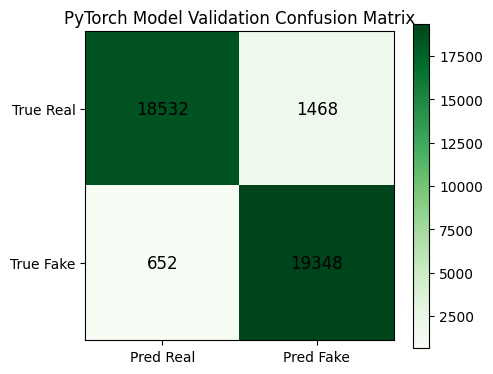

Saved checkpoint: /kaggle/working/outputs/pytorch_deepfake/deepfake_resnet18_best.pt
Saved history: /kaggle/working/outputs/pytorch_deepfake/train_history.csv
Saved validation predictions: /kaggle/working/outputs/pytorch_deepfake/val_predictions.csv


In [8]:
val_loss, y_true, y_score = evaluate(model, val_loader, criterion, device)
y_pred = (y_score >= 0.5).astype(np.int64)

final_metrics = {
    'val_loss': float(val_loss),
    'accuracy': float(accuracy_score(y_true, y_pred)),
    'precision': float(precision_score(y_true, y_pred, zero_division=0)),
    'recall': float(recall_score(y_true, y_pred, zero_division=0)),
    'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    'roc_auc': float(roc_auc_score(y_true, y_score)) if len(np.unique(y_true)) > 1 else float('nan'),
}

print('Final validation metrics:')
print(json.dumps(final_metrics, indent=2))
print('')
print(classification_report(y_true, y_pred, target_names=['real', 'fake'], zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Greens)
plt.colorbar(im, ax=ax)
ax.set(
    xticks=[0, 1],
    yticks=[0, 1],
    xticklabels=['Pred Real', 'Pred Fake'],
    yticklabels=['True Real', 'True Fake'],
    title='PyTorch Model Validation Confusion Matrix',
)
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.show()

history_path = OUTPUT_DIR / 'train_history.csv'
pred_path = OUTPUT_DIR / 'val_predictions.csv'
ckpt_path = OUTPUT_DIR / 'deepfake_resnet18_best.pt'

history_df.to_csv(history_path, index=False)
pd.DataFrame({
    'path': val_df['path'].tolist(),
    'y_true': y_true,
    'score': y_score,
    'pred': y_pred,
}).to_csv(pred_path, index=False)

torch.save({
    'model_name': 'resnet18_binary',
    'image_size': IMAGE_SIZE,
    'threshold': 0.5,
    'state_dict': model.state_dict(),
    'metrics': final_metrics,
    'normalization': {
        'mean': [0.485, 0.456, 0.406],
        'std': [0.229, 0.224, 0.225],
    },
}, ckpt_path)

print(f'Saved checkpoint: {ckpt_path}')
print(f'Saved history: {history_path}')
print(f'Saved validation predictions: {pred_path}')

In [9]:
from pathlib import Path

out = Path("/kaggle/working/outputs/pytorch_deepfake")
print("exists:", out.exists())
if out.exists():
    for p in out.iterdir():
        print(p)

exists: True
/kaggle/working/outputs/pytorch_deepfake/deepfake_resnet18_best.pt
/kaggle/working/outputs/pytorch_deepfake/val_predictions.csv
/kaggle/working/outputs/pytorch_deepfake/train_history.csv
